<a href="https://colab.research.google.com/github/chavezgranados/Quantitative-Methods/blob/main/notebooks/cuaderno11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">

<font face="gotham" color="#1B5E20"> Unidad de Posgrado de la Facultad de Economía </font>

<img src="https://yachay.digital/wp-content/uploads/2021/03/uncp.png" width="120">

<font face="gotham" color="#1B5E20"> **Curso: Métodos Cuantitativos Aplicados a la Investigación** </font>

<hr width="50%" color="#C9A227">

<font face="gotham" color="#1B5E20"> Maestría en Planificación y Proyectos de Inversión </font>

<font face="gotham" color="#1B5E20"> `Luis Chávez` </font>

<font face="gotham" color="#1B5E20"> 2026 </font>

# <font face="gotham" color="#E3B10D"> **Tópico: regresión y correlación**

In [ ]:
#===============================================================================
# Librerías
#===============================================================================
import zipfile
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from scipy.stats.mstats import winsorize

In [ ]:
pip install inei-microdatos

In [ ]:
import inei_microdatos

In [ ]:
from inei_microdatos import load_catalog, download_modules, read_module
from inei_microdatos.catalog import filter_catalog
catalog = load_catalog()

In [ ]:
enaho_2025 = filter_catalog(catalog, survey="enaho", year_min=2025, year_max=2025, period="Anual")

In [ ]:
download_modules(enaho_2025, dest="./2025", fmt="CSV")

{'ok': 0, 'skipped': 31, 'failed': 0, 'bad_zip': 0}

In [ ]:
def leer_enaho(zip_file, tabla):

    with zipfile.ZipFile(zip_file) as z:
        archivo = next(f for f in z.namelist()
            if tabla in f)
        return pd.read_csv(
            z.open(archivo),
            sep=";",
            encoding="latin1",
            low_memory=False)
base = "./2025/Condiciones de Vida y Pobreza - ENAHO/2025/Anual - (Ene-Dic)"

In [ ]:
# Módulo 300 ===================================================================
mod300 = leer_enaho(f"{base}/1031-Modulo03.zip", "Enaho01A-2025-300")
mod300.head()

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,CODPERSO,UBIGEO,DOMINIO,ESTRATO,CODINFOR,...,I311D$5,I311D$6,I311D$7,I3121C,I3122C,I315B,FACTOR07,FACTORA07,NCONGLOME,SUB_CONGLOME
0,2025,1,15009,12,11,1,10101,4,4,1,...,,,351,,,,"87,2856903076172","150,298141479492",7098,0
1,2025,1,15009,12,11,2,10101,4,4,2,...,,,,,,,"87,2856903076172","125,093391418457",7098,0
2,2025,1,15009,25,11,1,10101,4,4,1,...,,,,,,,"87,2856903076172","127,413833618164",7098,0
3,2025,1,15009,25,11,2,10101,4,4,2,...,,,,,,,"87,2856903076172","98,0374298095703",7098,0
4,2025,1,15009,25,11,3,10101,4,4,3,...,,,,,,,"87,2856903076172","93,3369903564453",7098,0


In [ ]:
mod300["P207"] = mod300["P207"].replace({2: 0}) # recodificar: 2 -> 0
mod300 = mod300.rename(columns={"P207": "varon"})

In [ ]:
mod300["urbano"] = np.where(mod300["ESTRATO"] <= 6, 1, 0) # crear la variable

In [ ]:
mod300["P302"] = mod300["P302"].replace({2: 0})
mod300 = mod300.rename(columns={"P302": "alfabet"}) # alfabetismo
mod300["alfabet"] = mod300["alfabet"].replace({9: np.nan})

In [ ]:
mod300["tmp_years"] = mod300[["P301B", "P301C"]].max(axis=1, skipna=True)
mod300["educ"] = np.nan

In [ ]:
mod300["tmp_years"] = pd.to_numeric(mod300["tmp_years"], errors='coerce')
mod300["P301A"] = pd.to_numeric(mod300["P301A"], errors='coerce')
# Primaria incompleta
mask = (mod300["P301A"] == 3) & (mod300["tmp_years"] < 6)
mod300.loc[mask, "educ"] = mod300.loc[mask, "tmp_years"]

# Primaria completa
mask = ((mod300["P301A"] == 3) & (mod300["tmp_years"] >= 6)) | (mod300["P301A"] == 4)
mod300.loc[mask, "educ"] = 6

# Secundaria incompleta
mask = (mod300["P301A"] == 5) & (mod300["tmp_years"] <= 5)
mod300.loc[mask, "educ"] = 6 + mod300.loc[mask, "tmp_years"]

# Secundaria completa
mask = ((mod300["P301A"] == 5) & (mod300["tmp_years"] >= 5)) | (mod300["P301A"] == 6)
mod300.loc[mask, "educ"] = 11

# Educación superior
mask = (mod300["P301A"] >= 7) & mod300["P301A"].notna() & mod300["tmp_years"].notna()
mod300.loc[mask, "educ"] = 11 + mod300.loc[mask, "tmp_years"]

# Renombrar nivel educativo
mod300 = mod300.rename(columns={"P301A": "level_educ"})

In [ ]:
mod300["educ"] = mod300["educ"].replace(110, np.nan)

In [ ]:
mod300["exp"] = mod300["P208A"] - mod300["educ"] - 6

In [ ]:
mod300.loc[mod300["exp"] < 0, "exp"] = np.nan

In [ ]:
mod300["exp2"] = mod300["exp"] ** 2

In [ ]:
mod300 = mod300.rename(columns={"DOMINIO": "dominio"})

In [ ]:
keywords = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
variables = ["varon", "dominio", "urbano", "alfabet", "educ", "level_educ", "exp", "exp2"]
mod300 = mod300[keywords + variables]

In [ ]:
# Módulo 500 ===================================================================
mod500 = leer_enaho(f"{base}/1031-Modulo05.zip", "Enaho01a-2025-500")
mod500.head()

,AÑO,MES,CONGLOME,VIVIENDA,HOGAR,CODPERSO,UBIGEO,DOMINIO,ESTRATO,CODINFOR,...,I538C1,I538D1,I538E1,I5294B,I5404B,I541A,OCU500,FAC500A,NCONGLOME,SUB_CONGLOME
0,2025,1,15009,12,11,1,10101,4,4,1,...,,,,,,5913,1,"150,298141479492",7098,0
1,2025,1,15009,12,11,2,10101,4,4,2,...,,,,,,,1,"125,093391418457",7098,0
2,2025,1,15009,25,11,1,10101,4,4,1,...,,,,,,,1,"127,413833618164",7098,0
3,2025,1,15009,25,11,2,10101,4,4,2,...,,,,,,,1,"98,0374298095703",7098,0
4,2025,1,15009,25,11,3,10101,4,4,3,...,,,,,,,4,"93,3369903564453",7098,0


In [ ]:
vars = ["P524A1", "P523", "P530A", "P538A1", "P541A", "P558C"]
mod500[vars] = mod500[vars].replace({999999: np.nan, 99999: np.nan})

In [ ]:
mod500["P523"] = pd.to_numeric(mod500["P523"], errors="coerce")
mod500["P524A1"] = pd.to_numeric(mod500["P524A1"], errors="coerce")
mod500["y_pri_dep"] = pd.Series(np.nan, index=mod500.index, dtype="float64")

In [ ]:
mod500["blanco"] = (mod500["P558C"] == 5).astype(int)
mod500["mestizo"] = (mod500["P558C"] == 6).astype(int)

In [ ]:
# Ingreso primario dependiente
mod500["y_pri_dep"] = np.nan

mask = mod500["P524A1"].notna() & mod500["P523"].notna()
mod500.loc[mask, "y_pri_dep"] = 0

# Diario (260 días laborales al año)
mask = mod500["P523"] == 1
mod500.loc[mask, "y_pri_dep"] = mod500.loc[mask, "P524A1"] * 260 / 12

# Semanal (52 semanas al año)
mask = mod500["P523"] == 2
mod500.loc[mask, "y_pri_dep"] = mod500.loc[mask, "P524A1"] * 52 / 12

# Quincenal
mask = mod500["P523"] == 3
mod500.loc[mask, "y_pri_dep"] = mod500.loc[mask, "P524A1"] * 2

# Mensual
mask = mod500["P523"] == 4
mod500.loc[mask, "y_pri_dep"] = mod500.loc[mask, "P524A1"]

In [ ]:
# Ingreso primario independiente
mod500 = mod500.rename(columns={"P530A": "y_pri_indep"})
mod500["y_pri_indep"] = pd.to_numeric(mod500["y_pri_indep"], errors="coerce")

In [ ]:
# Ingreso primario total
mod500["y_pri"] = mod500[["y_pri_dep", "y_pri_indep"]].sum(axis=1, min_count=1)
mod500["y_pri"] = pd.to_numeric(mod500["y_pri"], errors="coerce")

In [ ]:
# Ingreso secundario
mod500 = mod500.rename(columns={"P538A1": "y_sec_dep", "P541A": "y_sec_ind"})
mod500["y_sec"] = mod500[["y_sec_dep", "y_sec_ind"]].sum(axis=1, min_count=1)
mod500["y_sec"] = pd.to_numeric(mod500["y_sec"], errors="coerce")

In [ ]:
# Ingreso laboral total
mod500["ing"] = mod500[["y_pri", "y_sec"]].sum(axis=1, min_count=1)

In [ ]:
mod500["ing"] = mod500["ing"].replace({999999: np.nan})

In [ ]:
keywords = ["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"]
variables = ["ing", "blanco", "mestizo"]
mod500 = mod500[keywords + variables]

In [ ]:
datos = pd.merge(mod300,  mod500, on=["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"], how="inner", validate="one_to_one")
datos = datos.drop(columns=["CONGLOME", "VIVIENDA", "HOGAR", "CODPERSO"])

In [ ]:
Q1 = datos["ing"].quantile(0.25)
Q3 = datos["ing"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
datos= datos[(datos["ing"] >= lower_bound) & (datos["ing"] <= upper_bound)]

In [ ]:
datos = datos.dropna()
datos.head()

,varon,dominio,urbano,alfabet,educ,level_educ,exp,exp2,ing,blanco,mestizo,ln_ing
0,1,4,1,,13.0,11,26.0,676.0,3800.0,0,0,8.266678
1,0,4,1,,13.0,9,1.0,1.0,180.0,0,0,5.192957
2,1,4,1,,11.0,6,25.0,625.0,2300.0,0,0,7.740664
3,0,4,1,,9.0,5,21.0,441.0,346.0,0,0,5.846439
6,0,4,1,,14.0,8,24.0,576.0,1300.0,0,0,7.170120


In [ ]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 42357 entries, 0 to 84852
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   varon       42357 non-null  int64  
 1   dominio     42357 non-null  int64  
 2   urbano      42357 non-null  int64  
 3   alfabet     4705 non-null   float64
 4   educ        42357 non-null  float64
 5   level_educ  42357 non-null  int64  
 6   exp         42357 non-null  float64
 7   exp2        42357 non-null  float64
 8   ing         42357 non-null  float64
 9   blanco      42357 non-null  int64  
 10  mestizo     42357 non-null  int64  
 11  ln_ing      42357 non-null  float64
dtypes: float64(6), int64(6)
memory usage: 4.2 MB


## **1. Correlación**

In [ ]:
vars_corr = ["exp", "exp2", "ing"]

In [ ]:
corr = datos[vars_corr].corr()
corr

,exp,exp2,ing
exp,1.000000,0.950839,-0.165700
exp2,0.950839,1.000000,-0.231057
ing,-0.165700,-0.231057,1.000000


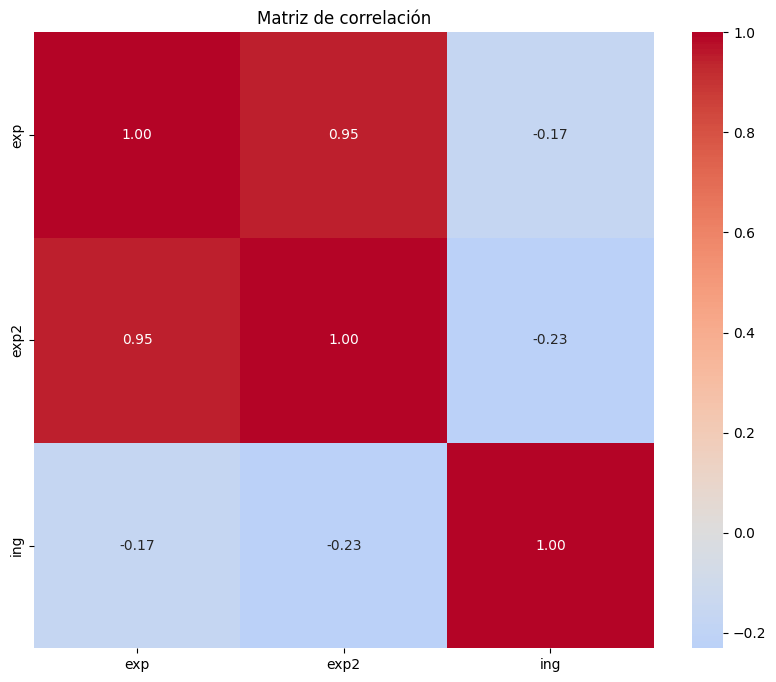

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)
plt.title("Matriz de correlación")
plt.show()

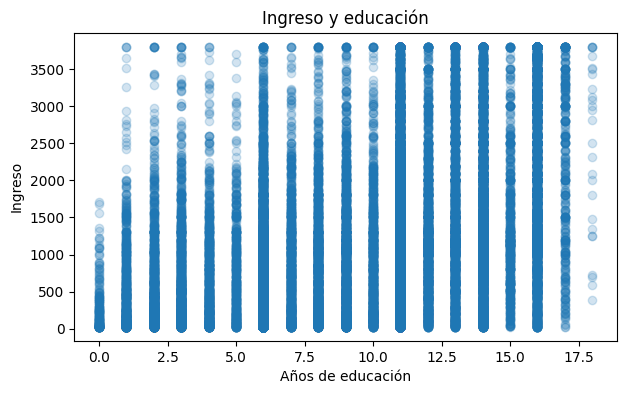

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(datos["educ"],
    datos["ing"],
    alpha=0.2)
plt.xlabel("Años de educación")
plt.ylabel("Ingreso")
plt.title("Ingreso y educación")
plt.show()

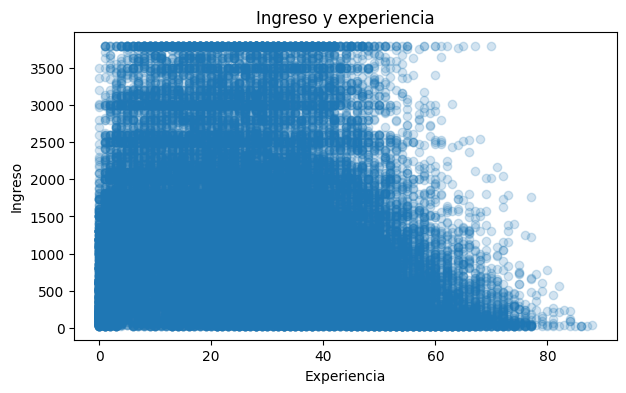

In [ ]:
plt.figure(figsize=(7,4))
plt.scatter(datos["exp"],
    datos["ing"],
    alpha=0.2)
plt.xlabel("Experiencia")
plt.ylabel("Ingreso")
plt.title("Ingreso y experiencia")
plt.show()

## **2. Regresión simple**

In [ ]:
datos["ln_ing"] = np.log(datos["ing"])

In [ ]:
X = datos["educ"]
y = datos["ln_ing"]

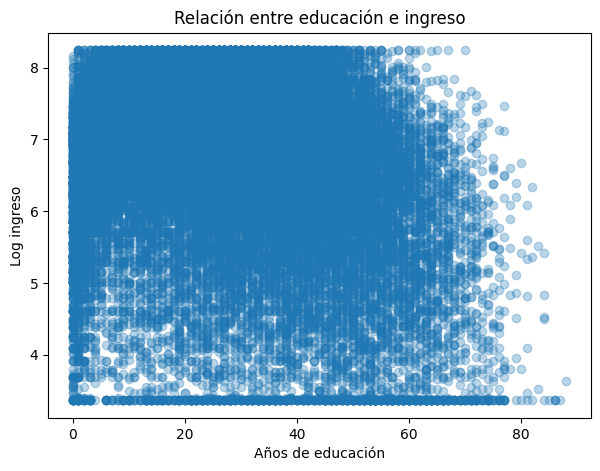

In [ ]:
plt.figure(figsize=(7,5))

plt.scatter(datos["exp"], datos["ln_ing"], alpha=0.3)

plt.xlabel("Años de educación")
plt.ylabel("Log ingreso")

plt.title("Relación entre educación e ingreso")

plt.show()

In [ ]:
X = sm.add_constant(X)
modelo1 = sm.OLS(y, X).fit()
print(modelo1.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_ing   R-squared:                       0.175
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     8973.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:45:27   Log-Likelihood:                -60845.
No. Observations:               42357   AIC:                         1.217e+05
Df Residuals:                   42355   BIC:                         1.217e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.4886      0.014    397.684      0.0

## **3. Regresión múltiple**

In [ ]:
X = datos[["educ", "exp", "exp2", "varon", "urbano"]]
X = sm.add_constant(X)
y = datos["ln_ing"]
modelo_mincer = sm.OLS(y, X).fit()
print(modelo_mincer.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_ing   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     3235.
Date:                Sat, 11 Jul 2026   Prob (F-statistic):               0.00
Time:                        17:53:46   Log-Likelihood:                -58065.
No. Observations:               42357   AIC:                         1.161e+05
Df Residuals:                   42351   BIC:                         1.162e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.9484      0.022    223.057      0.0

In [ ]:
print(f"AIC: {modelo_mincer.aic}")
print(f"BIC: {modelo_mincer.bic}")